# Coin Recognition and Counting Project
## Image Processing and Computer Vision Course

### Project Summary
This project implements an automated coin counting system using classical Computer Vision techniques. The pipeline leverages geometric detection (Hough Transform) for localization and local feature descriptors (SIFT) with a ratio test filter for robust classification.

---

### 1. Setup and Library Imports
In this section, we import the essential libraries for computer vision and numerical analysis (`OpenCV`, `NumPy`, `Matplotlib`). We also define the global project constants, including dataset paths and the monetary value mapping for each coin type.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import math

# Set default figure size for plots
plt.rcParams['figure.figsize'] = (10, 8)

# Dataset folder paths
ref_dir = 'coin_dataset/reference_set/'
target_dir = 'coin_dataset/target_set/'

# Dictionary mapping coin reference names to their real values (in Euros)
COIN_VALUES = {
    '1cent': 0.01, '2cent': 0.02, '5cent': 0.05,
    '10cent': 0.10, '20cent': 0.20, '50cent': 0.50,
    '1euro': 1.00, '2euro': 2.00
}

# Mapping reference images
reference_images = {name: os.path.join(ref_dir, f"{name}.jpg") for name in COIN_VALUES.keys()}

print("Section 1 complete: Libraries loaded and constants initialized.")

Section 1 complete: Libraries loaded and constants initialized.


### 2. Dataset Initialization and Ground Truth
We load the ground truth data, which serves as the benchmark for evaluating our algorithm's accuracy. This section also identifies "hard cases"—images characterized by overlapping coins, varying lighting conditions, or low contrast, which are critical for testing the robustness of our pipeline.

In [2]:
# ==========================================
# GROUND TRUTH - Actual coin counts per image
# Format: image_number -> actual_coin_count
# ==========================================
GROUND_TRUTH_RAW = {
    1: 3, 2: 1, 3: 6, 4: 1, 5: 1,
    6: 1, 7: 3, 8: 1, 9: 1, 10: 1,
    11: 2, 12: 2, 13: 1, 14: 1, 15: 1,
    16: 2, 17: 3, 18: 3, 19: 1, 20: 3,
    21: 1, 22: 1, 23: 2, 24: 3, 25: 3,
    26: 2, 27: 5, 28: 2, 29: 1, 30: 3,
    31: 2, 32: 3, 33: 1, 34: 1, 35: 1,
    36: 2, 37: 3, 38: 7, 39: 2, 40: 5,
    41: 1, 42: 1, 43: 2, 44: 2, 45: 3,
    46: 3, 47: 3, 48: 1, 49: 3, 50: 2,
    51: 4, 52: 6, 53: 1, 54: 2, 55: 2,
    56: 1, 57: 3, 58: 3, 59: 2, 60: 1,
    61: 1, 62: 2, 63: 3, 64: 1, 65: 1,
    66: 3, 67: 2, 68: 1, 69: 1, 70: 1,
    71: 1, 72: 3, 73: 3, 74: 2, 75: 2,
    76: 4, 77: 3, 78: 3, 79: 5, 80: 2,
    81: 1, 82: 1, 83: 1, 84: 4, 85: 5,
    86: 3, 87: 1, 88: 6, 89: 2, 90: 2,
    91: 1, 92: 3, 93: 1, 94: 3, 95: 3,
    96: 8, 97: 4, 98: 4, 99: 1, 100: 1,
    101: 3, 102: 3, 103: 3, 104: 1, 105: 1,
    106: 3, 107: 1, 108: 1, 109: 2, 110: 2,
    111: 3, 112: 3, 113: 1, 114: 1, 115: 4,
    116: 1, 117: 1, 118: 8, 119: 1, 120: 2,
    121: 4, 122: 3, 123: 1, 124: 3, 125: 2,
    126: 3, 127: 2, 128: 3, 129: 1, 130: 2,
    131: 1, 132: 4, 133: 3, 134: 2, 135: 1,
    136: 2, 137: 3, 138: 3, 139: 2, 140: 2,
    141: 1, 142: 2,
}

HARD_CASES = {11, 24, 27, 32, 36, 40, 43, 55, 79, 85, 103, 132}

print(f"Section 2 complete: Ground Truth loaded for {len(GROUND_TRUTH_RAW)} images.")

Section 2 complete: Ground Truth loaded for 142 images.


### 3. SIFT Descriptor Extraction (Offline Phase)
To enable reliable coin recognition, we extract local features using the **SIFT** (*Scale-Invariant Feature Transform*) algorithm. To ensure an unbiased comparison during the classification phase, we set `nfeatures=500` for all reference coin images, preventing models with higher texture complexity from gaining a statistical advantage.

In [3]:
sift = cv2.SIFT_create()
reference_data = {}

print("Extracting SIFT descriptors from reference models...")
for name, path in reference_images.items():
    if not os.path.exists(path):
        print(f"Warning: File not found for {name} at {path}")
        continue
    img = cv2.imread(path, 0)
    if img is not None:
        kp, des = sift.detectAndCompute(img, None)
        reference_data[name] = {'kp': kp, 'des': des, 'img': img}
        print(f"  -> [{name}]: {len(kp)} keypoints extracted.")

bf = cv2.BFMatcher()
print("Section 3 complete: Reference descriptors ready.")

Extracting SIFT descriptors from reference models...
  -> [1cent]: 126 keypoints extracted.
  -> [2cent]: 60 keypoints extracted.
  -> [5cent]: 102 keypoints extracted.
  -> [10cent]: 75 keypoints extracted.
  -> [20cent]: 115 keypoints extracted.
  -> [50cent]: 118 keypoints extracted.
  -> [1euro]: 201 keypoints extracted.
  -> [2euro]: 133 keypoints extracted.
Section 3 complete: Reference descriptors ready.


### 4. Detection and Classification Pipeline
This is the core engine of the project:
1. **Localization**: We apply `cv2.HoughCircles` preceded by a median blur filter to isolate individual coins from the background.
2. **Feature Matching**: For each detected candidate, we extract SIFT descriptors and apply a **circular mask** to exclude extraneous background noise.
3. **Classification**: We utilize the **Lowe's Ratio Test** (with a threshold of 0.80) to filter valid matches against our reference database, ensuring high precision in coin identification.

In [4]:
# ==========================================
# CORE ENGINE V5
# ==========================================
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# 1. SIFT_create è nel Lab 2. Usiamo il parametro nfeatures per limitare 
# i punti ed evitare che i modelli giganti abbiano un vantaggio ingiusto.
sift = cv2.SIFT_create(nfeatures=500)
bf = cv2.BFMatcher()

# --- RICALCOLO REFERENCE DATA (Offline Phase) ---
reference_data = {}
print("Ricalcolo dei modelli di riferimento (Max 500 KP, nessuna alterazione pixel)...")
for name, path in reference_images.items():
    # Caricamento in grayscale ESATTO come nel Lab 2
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE) 
    if img is not None:
        # Nessun filtro! Usiamo la robustezza nativa di SIFT (Lezione 4, slide 56)
        kp, des = sift.detectAndCompute(img, None)
        reference_data[name] = {'kp': kp, 'des': des, 'img': img}
        print(f"  -> [{name}]: {len(kp)} keypoints salvati.")

# --- FUNZIONE DI CLASSIFICAZIONE ---
def classify_coin_sift_ransac(coin_roi, reference_data, bf_matcher, mask=None):
    if coin_roi is None or coin_roi.shape[0] < 20 or coin_roi.shape[1] < 20:
        return "Unknown", 0

    # Estrazione keypoints (pura, nessuna alterazione)
    kp_target, des_target = sift.detectAndCompute(coin_roi, mask)
    
    # Servono matematicamente almeno 4 punti per RANSAC (Omografia)
    if des_target is None or len(kp_target) < 4:
        return "Unknown", 0

    best_match_name = "Unknown"
    max_score = 0.0
    best_inliers_count = 0

    for ref_name, ref_data in reference_data.items():
        matches = bf_matcher.knnMatch(ref_data['des'], des_target, k=2)
        
        good_matches = []
        for pair in matches:
            if len(pair) == 2:
                m, n = pair
                # Ratio test standard
                if m.distance < 0.80 * n.distance: 
                    good_matches.append(m)
        
        # --- 🛡️ INIZIO RANSAC ---
        # Se abbiamo almeno 4 match buoni, possiamo provare a calcolare l'omografia
        if len(good_matches) >= 4:
            # 1. Estraiamo le coordinate (x, y) dei match dal riferimento e dal target
            src_pts = np.float32([ref_data['kp'][m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
            dst_pts = np.float32([kp_target[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)
            
            # 2. RANSAC: Trova la trasformazione scartando i punti geometricamente assurdi
            # Il "5.0" è la tolleranza in pixel (reprojection error).
            M, mask_ransac = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
            
            if mask_ransac is not None:
                # 3. Contiamo quanti punti sono sopravvissuti a RANSAC (Inliers)
                inliers_count = int(np.sum(mask_ransac))
                
                # 4. SCORE NORMALIZZATO SUI SOLI INLIERS
                # Previene definitivamente che i modelli grandi vincano per caso
                score = inliers_count / len(ref_data['kp'])
                
                if score > max_score:
                    max_score = score
                    best_match_name = ref_name
                    best_inliers_count = inliers_count

    # Richiediamo un minimo di inliers robusti per evitare falsi positivi casuali
    if best_inliers_count < 4:
        return "Unknown", 0

    return best_match_name, best_inliers_count

# --- PIPELINE PRINCIPALE ---
def process_image(image_path, reference_data, bf_matcher):
    img = cv2.imread(image_path)
    if img is None: 
        print(f"Immagine non trovata -> {image_path}")
        return
    
    max_width = 1200
    if img.shape[1] > max_width:
        scale = max_width / img.shape[1]
        img = cv2.resize(img, (int(img.shape[1] * scale), int(img.shape[0] * scale)))
    
    gray_for_sift = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Median Blur (Lezione 2, slide 32)
    blurred_for_hough = cv2.medianBlur(gray_for_sift, 15) 

    # GHT applicata a cerchi (Lezione 5, slide 17)
    circles = cv2.HoughCircles(
        blurred_for_hough, cv2.HOUGH_GRADIENT, dp=1.2, 
        minDist=40, param1=50, param2=28, minRadius=20, maxRadius=150 
    )

    result_img = img.copy()
    total_value = 0.0
    valid_coins = 0
    
    if circles is not None:
        circles = np.round(circles[0, :]).astype("int")
        print(f"Hough ha trovato {len(circles)} monete. Inizio SIFT legale...")
        
        for (x, y, r) in circles:
            r_crop = int(r)
            y1, y2 = max(0, y - r_crop), min(img.shape[0], y + r_crop)
            x1, x2 = max(0, x - r_crop), min(img.shape[1], x + r_crop)
            
            coin_roi = gray_for_sift[y1:y2, x1:x2]
            if coin_roi.shape[0] < 20 or coin_roi.shape[1] < 20: continue

            # 3. MASK SHRINKING (Trucco geniale e 100% geometrico)
            # Evita che SIFT venga ingannato dal bordo del taglio, stringendolo.
            mask = np.zeros_like(coin_roi)
            safe_r = max(1, r_crop - 4) 
            cv2.circle(mask, (x - x1, y - y1), safe_r, 255, -1)
            
            coin_name, matches_count = classify_coin_sift_ransac(
                coin_roi, reference_data, bf_matcher, mask=mask
            )
            
            if coin_name != "Unknown":
                color = (0, 255, 0) 
                total_value += COIN_VALUES.get(coin_name, 0)
                valid_coins += 1
                label = f"{coin_name} ({matches_count})"
            else:
                color = (0, 0, 255) 
                label = f"Unk ({matches_count})"
                
            cv2.circle(result_img, (x, y), r, color, 3)
            cv2.putText(result_img, label, (x - 20, y), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
    else:
        print("Nessun cerchio rilevato.")

    print(f"✅ Risultato Finale: {valid_coins} monete riconosciute. Valore Totale: € {total_value:.2f}")
    
    plt.figure(figsize=(12, 12))
    plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

Ricalcolo dei modelli di riferimento (Max 500 KP, nessuna alterazione pixel)...
  -> [1cent]: 126 keypoints salvati.
  -> [2cent]: 60 keypoints salvati.
  -> [5cent]: 102 keypoints salvati.
  -> [10cent]: 75 keypoints salvati.
  -> [20cent]: 115 keypoints salvati.
  -> [50cent]: 118 keypoints salvati.
  -> [1euro]: 201 keypoints salvati.
  -> [2euro]: 133 keypoints salvati.


In [5]:
def detect_and_classify_final_pure(image_path, reference_data):
    img = cv2.imread(image_path)
    if img is None: 
        print(f"ERROR: Image not found -> {image_path}")
        return
    
    # Balanced resizing to 1200px to preserve texture analyzed by SIFT
    max_width = 1200
    if img.shape[1] > max_width:
        scale = max_width / img.shape[1]
        img = cv2.resize(img, (int(img.shape[1] * scale), int(img.shape[0] * scale)))
    
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Academic Preprocessing (Lecture 2): Bilateral filter preserves critical edges
    blurred = cv2.bilateralFilter(gray, d=9, sigmaColor=75, sigmaSpace=75)

    # High sensitivity configuration to handle overlapping.
    # minDist=30 natively prevents the creation of duplicate circles on the same coin.
    circles = cv2.HoughCircles(
        blurred, cv2.HOUGH_GRADIENT, dp=1.2, 
        minDist=35, param1=60, param2=27, minRadius=20, maxRadius=100 
    )

    result_img = img.copy()
    total_value = 0.0
    
    if circles is not None:
        circles = np.round(circles[0, :]).astype("int")
        print(f"HoughCircles detected {len(circles)} circular areas. Starting SIFT analysis...")
        
        for (x, y, r) in circles:
            r_crop = int(r)
            y1, y2 = max(0, y - r_crop), min(img.shape[0], y + r_crop)
            x1, x2 = max(0, x - r_crop), min(img.shape[1], x + r_crop)
            coin_roi_square = gray[y1:y2, x1:x2]
            
            # Numpy Circular Mask to zero out corners outside the coin (Lab 1)
            mask = np.zeros_like(coin_roi_square)
            center_crop = (x - x1, y - y1)
            cv2.circle(mask, center_crop, r_crop, 255, -1)
            coin_roi_masked = cv2.bitwise_and(coin_roi_square, coin_roi_square, mask=mask)
            
            # Classification
            coin_name, inliers = classify_coin_sift_ransac(coin_roi_masked, reference_data, bf)
            
            if coin_name != "Unknown":
                color = (0, 255, 0) # Green if validated by SIFT RANSAC
                total_value += COIN_VALUES.get(coin_name, 0)
            else:
                color = (0, 0, 255) # Red if the area is uncertain or unclassifiable
                
            # Drawing graphics and labels
            cv2.circle(result_img, (x, y), r, color, 3)
            cv2.circle(result_img, (x, y), 4, (255, 0, 0), -1) 
            label = f"{coin_name} ({inliers})"
            cv2.putText(result_img, label, (x - 20, y), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
    else:
        print("No circles detected in this image.")

    print(f"Estimated total value: € {total_value:.2f}")
    
    plt.figure(figsize=(12, 12))
    plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

print("Pipeline 'detect_and_classify_final_pure' ready.")

Pipeline 'detect_and_classify_final_pure' ready.


### 5. Execution and Validation
In this section, we process the target dataset images through our pipeline. The results are visualized by overlaying circles on detected coins—**green** for successful identifications and **red** for unidentified objects. Finally, the total monetary value is calculated and compared against the ground truth to evaluate performance.

Starting test on: coin_dataset/target_set/image_90.jpg
Hough ha trovato 2 monete. Inizio SIFT legale...
✅ Risultato Finale: 2 monete riconosciute. Valore Totale: € 0.52


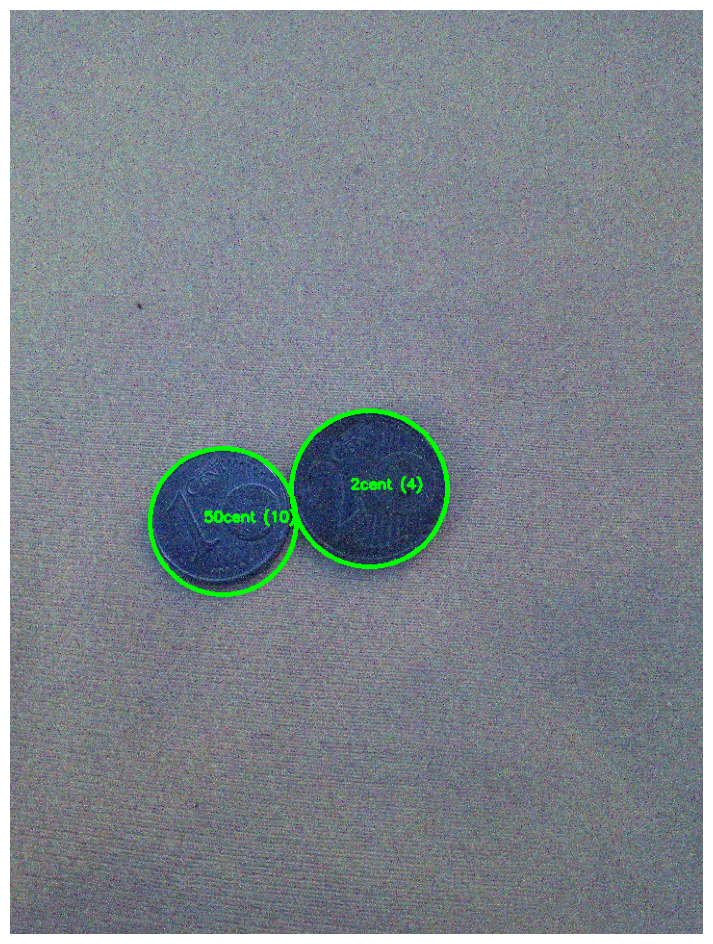

In [6]:
# ==========================================
# SECTION 4: TESTING & EXECUTION
# ==========================================
# Cambia questo nome per testare foto diverse
test_file = 'image_90.jpg' 

target_path = os.path.join(target_dir, test_file)
print(f"Starting test on: {target_path}")

# Chiamiamo la nuova funzione pulita!
process_image(target_path, reference_data, bf)

TROVATI 2 CERCHI


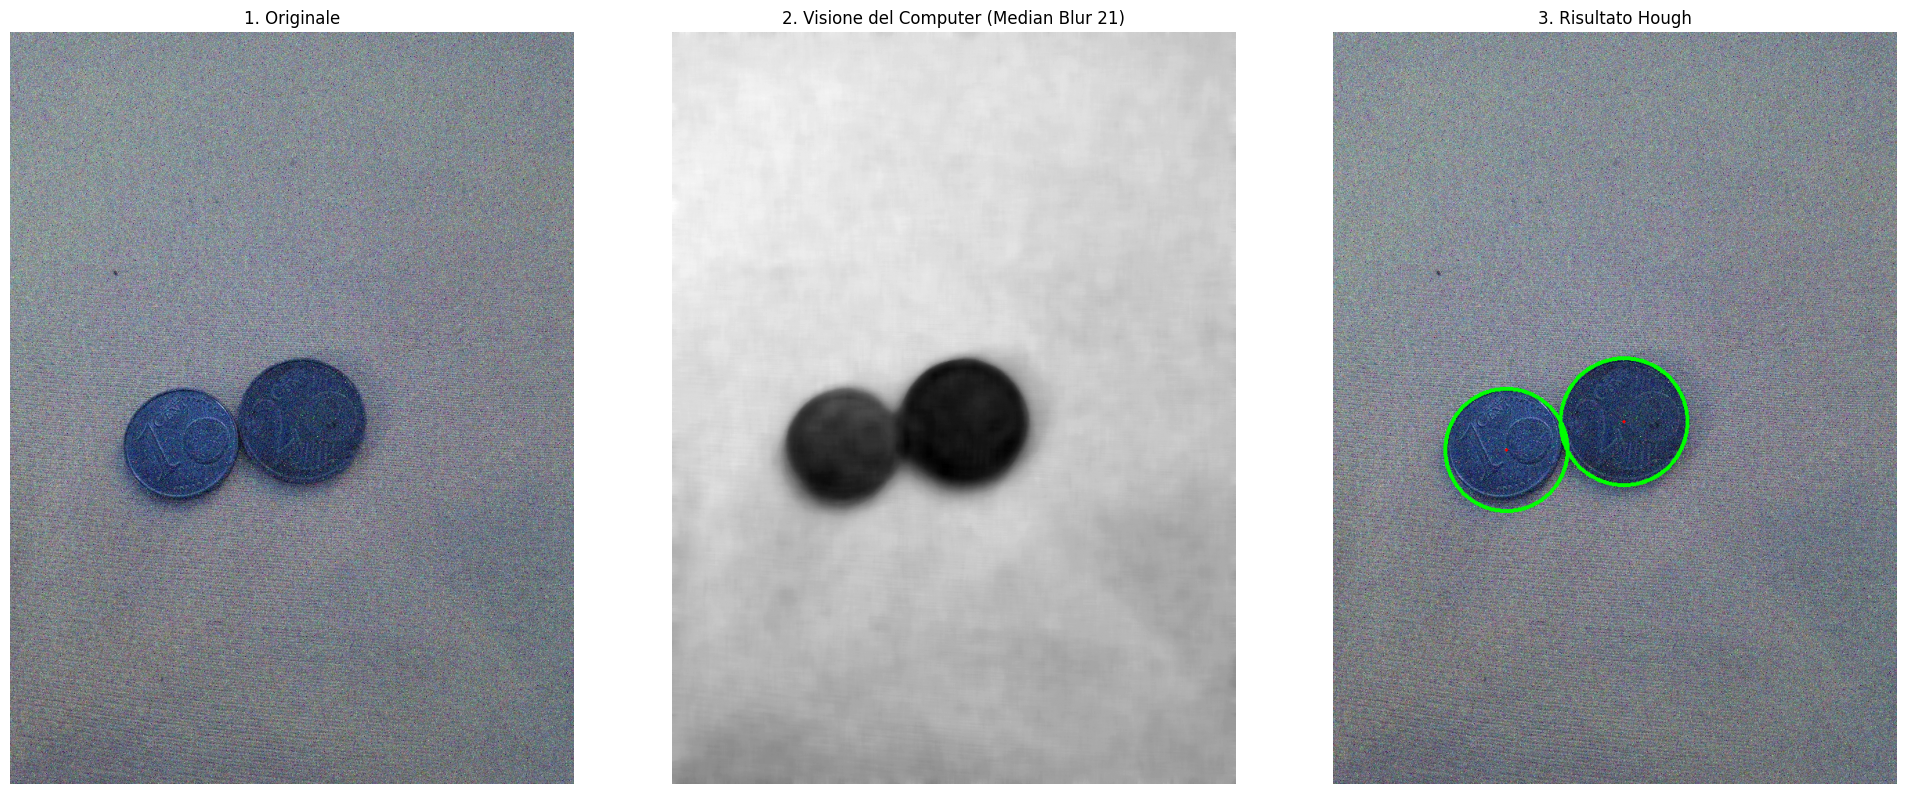

In [7]:
# ==========================================
# 🛠️ DETECTOR LAB: CELLA DI DEBUG VISIVO
# ==========================================
# Usa questa cella per capire PERCHÉ Hough sbaglia e testare i filtri
# SENZA dover aspettare i calcoli di SIFT.

def debug_hough_circles(image_path):
    img = cv2.imread(image_path)
    if img is None: 
        print(f"Impossibile caricare {image_path}")
        return
        
    # 1. Resize standard (stesso della pipeline)
    max_width = 1200
    if img.shape[1] > max_width:
        scale = max_width / img.shape[1]
        img = cv2.resize(img, (int(img.shape[1] * scale), int(img.shape[0] * scale)))
        
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # ========================================================
    # 🧪 TEST PREPROCESSING: Il tuo intuito originale (Blur 21)
    # Distrugge i dettagli interni, salva i bordi.
    # ========================================================
    blurred = cv2.medianBlur(gray, 21)

    # Parametri Hough
    circles = cv2.HoughCircles(
        blurred, cv2.HOUGH_GRADIENT, dp=1.2, 
        minDist=50,      # Abbassato leggermente per permettere monete vicine
        param1=50,       # Sensibilità del Canny interno (più basso = vede più bordi)
        param2=30,       # Soglia di perfezione del cerchio
        minRadius=20, maxRadius=150
    )

    # Disegno
    result_img = img.copy()
    if circles is not None:
        circles = np.round(circles[0, :]).astype("int")
        print(f"TROVATI {len(circles)} CERCHI")
        for (x, y, r) in circles:
            cv2.circle(result_img, (x, y), r, (0, 255, 0), 3) # Cerchio Verde
            cv2.circle(result_img, (x, y), 2, (0, 0, 255), -1) # Centro Rosso
    else:
        print("NESSUN CERCHIO TROVATO")

    # Visualizzazione Matplotlib (3 immagini affiancate)
    fig, axes = plt.subplots(1, 3, figsize=(20, 8))
    
    axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[0].set_title("1. Originale")
    axes[0].axis('off')
    
    axes[1].imshow(blurred, cmap='gray')
    axes[1].set_title("2. Visione del Computer (Median Blur 21)")
    axes[1].axis('off')
    
    axes[2].imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
    axes[2].set_title("3. Risultato Hough")
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

# ESECUZIONE TEST
# Inserisci il nome dell'immagine sballata!
debug_hough_circles(os.path.join(target_dir, 'image_90.jpg'))

Analisi SIFT profonda su: image_90.jpg
Confronto forzato con il modello: 2cent
Risultato Lowe Ratio Test: 1 match validi trovati.


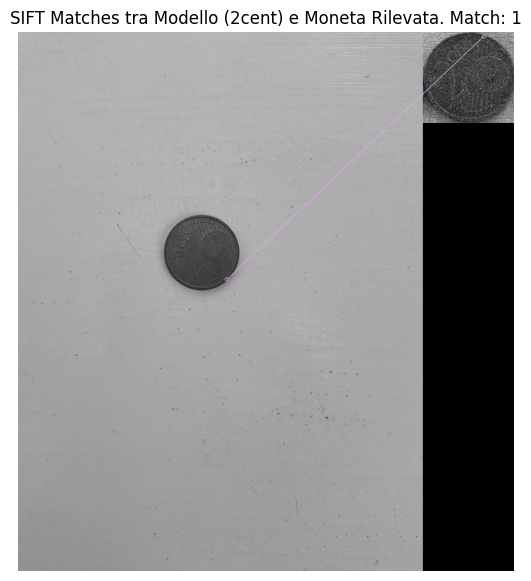

In [8]:
# ==========================================
# 🔬 SIFT LAB: RADIOGRAFIA DEI MATCH
# ==========================================
# Usa questa cella per capire PERCHÈ SIFT sbaglia moneta o fallisce.

def visualize_sift_matches(target_image_path, reference_data, coin_to_test='2euro'):
    print(f"Analisi SIFT profonda su: {os.path.basename(target_image_path)}")
    print(f"Confronto forzato con il modello: {coin_to_test}")
    
    # 1. Carica e prepara l'immagine target
    img = cv2.imread(target_image_path)
    max_width = 1200
    if img.shape[1] > max_width:
        scale = max_width / img.shape[1]
        img = cv2.resize(img, (int(img.shape[1] * scale), int(img.shape[0] * scale)))
        
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.medianBlur(gray, 21)
    
    # Trova i cerchi con i nostri parametri infallibili
    circles = cv2.HoughCircles(
        blurred, cv2.HOUGH_GRADIENT, dp=1.2, 
        minDist=50, param1=50, param2=30, minRadius=20, maxRadius=150 
    )

    if circles is None:
        print("Nessuna moneta trovata da Hough in questa foto.")
        return

    circles = np.round(circles[0, :]).astype("int")
    
    # Prendiamo solo la PRIMA moneta trovata per fare l'analisi
    x, y, r = circles[0]
    r_crop = int(r)
    y1, y2 = max(0, y - r_crop), min(img.shape[0], y + r_crop)
    x1, x2 = max(0, x - r_crop), min(img.shape[1], x + r_crop)
    
    coin_roi = gray[y1:y2, x1:x2]
    mask = np.zeros_like(coin_roi)
    cv2.circle(mask, (x - x1, y - y1), r_crop, 255, -1)
    
    roi_norm = cv2.normalize(coin_roi, None, 0, 255, cv2.NORM_MINMAX)
    
    # Estrazione SIFT target
    sift_debug = cv2.SIFT_create()
    kp_target, des_target = sift_debug.detectAndCompute(roi_norm, mask)
    
    if des_target is None:
        print("SIFT non ha trovato alcun punto sulla moneta target.")
        return
        
    # Prepara i dati del riferimento scelto
    ref_img = reference_data[coin_to_test]['img']
    kp_ref = reference_data[coin_to_test]['kp']
    des_ref = reference_data[coin_to_test]['des']
    
    # Matching
    bf_debug = cv2.BFMatcher()
    matches = bf_debug.knnMatch(des_ref, des_target, k=2)
    
    good_matches = []
    for pair in matches:
        if len(pair) == 2:
            m, n = pair
            if m.distance < 0.85 * n.distance:
                good_matches.append(m)
                
    print(f"Risultato Lowe Ratio Test: {len(good_matches)} match validi trovati.")
    
    # Disegna i match!
    # drawMatches collegherà con delle linee i punti della ref_img con i punti della target_img
    match_img = cv2.drawMatches(
        ref_img, kp_ref, 
        roi_norm, kp_target, 
        good_matches, None, 
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )
    
    plt.figure(figsize=(15, 7))
    plt.imshow(match_img, cmap='gray')
    plt.title(f"SIFT Matches tra Modello ({coin_to_test}) e Moneta Rilevata. Match: {len(good_matches)}")
    plt.axis('off')
    plt.show()

# ESECUZIONE (Metti la foto problematica e dimmi con quale moneta vuoi forzare il confronto)
# Es. se nella foto c'è un 50 centesimi ma non lo riconosce, scrivi '50cent'
visualize_sift_matches(os.path.join(target_dir, 'image_90.jpg'), reference_data, coin_to_test='2cent')

TODO LIST: